In [1]:
import numpy as np
from core.moment import perturb_activations_MOMENT
from core.perturb import add
from core.steering import get_steering_matrix
from utils import get_sample_from_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

/Users/michalwilinski/Work/tsfm_interrogation/envs/interrogator/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/Users/michalwilinski/Work/tsfm_interrogation/envs/interrogator/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [2]:
METHOD = 'median'
LAYER_TO_PLOT = 15
ONE_ACTIVATIONS = 'activations/none_constant_activations.npy'
OTHER_ACTIVATIONS = 'activations/sine_constant_activations.npy'
INPUT_SAMPLE = ('datasets/none_constant.parquet', 0)
PLOT_SAVE_PATH = f"moment_viz/steering_sine_constant/constant_to_sine_{METHOD}.pdf"

## Getting samples and steering vectors

In [3]:
one_activations = np.load(ONE_ACTIVATIONS) # (layer, batch, patch, features)
other_activations = np.load(OTHER_ACTIVATIONS)
one_sample = get_sample_from_dataset(pd.read_parquet(INPUT_SAMPLE[0]), INPUT_SAMPLE[1])
one_to_other_steering_matrix = get_steering_matrix(one_activations, other_activations, method=METHOD)

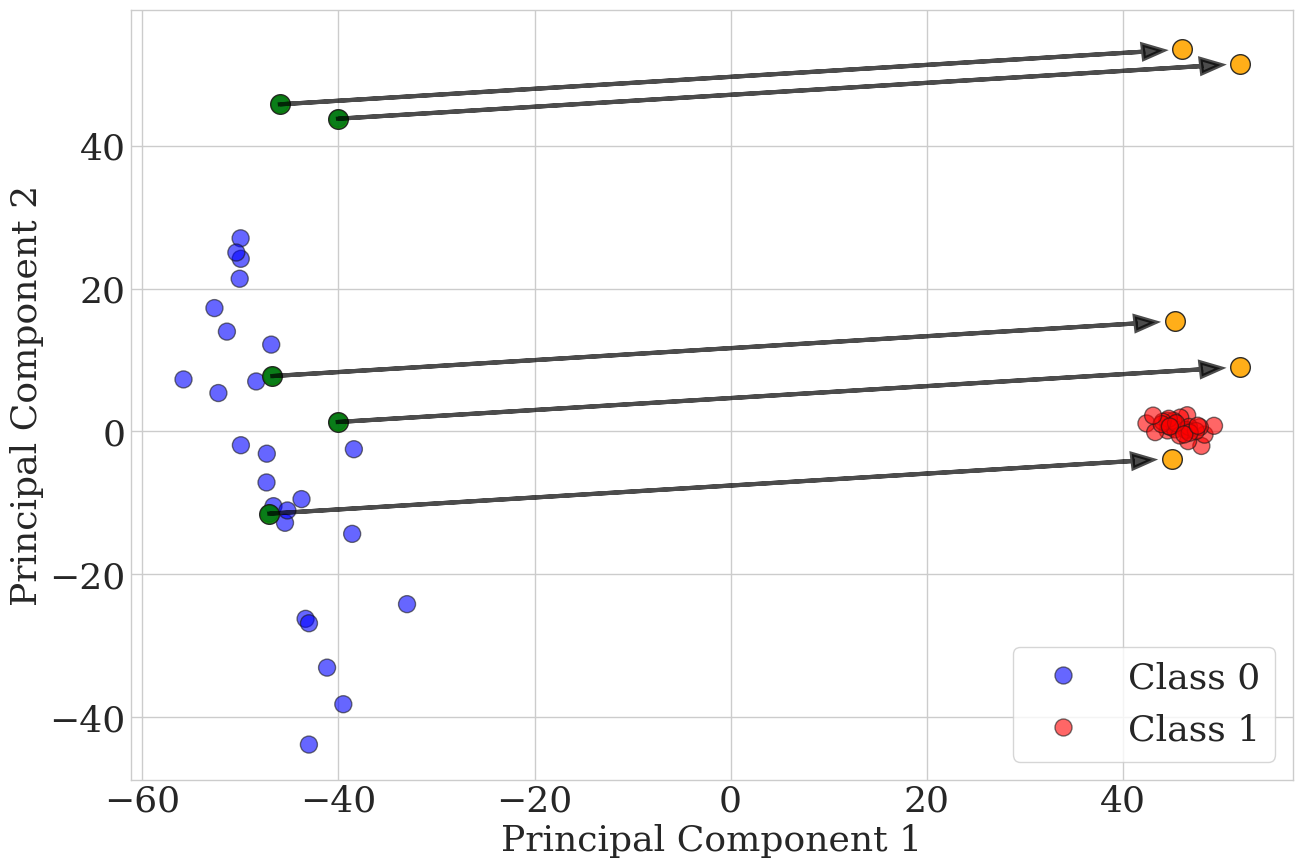

In [4]:
# Assume one_activations, other_activations, and one_to_other_steering_matrix are already loaded
one_activations_plot = one_activations[LAYER_TO_PLOT, :30, :, :]
other_activations_plot = other_activations[LAYER_TO_PLOT, :30, :, :]

# Select 5 random activations from the first dataset for perturbation
random_indices = np.random.choice(one_activations_plot.shape[0], 5, replace=False)
one_activations_to_perturb = one_activations_plot[random_indices]
steering_matrix_for_layer = one_to_other_steering_matrix[LAYER_TO_PLOT]
one_activations_perturbed = one_activations_to_perturb.copy() + steering_matrix_for_layer

# Average the activations over the patches
one_activations_plot = np.mean(one_activations_plot, axis=1)
other_activations_plot = np.mean(other_activations_plot, axis=1)
one_activations_to_perturb = np.mean(one_activations_to_perturb, axis=1)
one_activations_perturbed = np.mean(one_activations_perturbed, axis=1)

# Perform PCA on the activations
one_activations_plot = one_activations_plot.reshape(-1, one_activations_plot.shape[-1])
other_activations_plot = other_activations_plot.reshape(-1, other_activations_plot.shape[-1])

dataset_with_labels = np.concatenate([one_activations_plot, other_activations_plot], axis=0)
labels = np.concatenate([np.zeros(one_activations_plot.shape[0]), np.ones(other_activations_plot.shape[0])])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(dataset_with_labels)
pca_df = pd.DataFrame(pca_result, columns=['pca1', 'pca2'])
pca_df['labels'] = labels

# Apply PCA transformation on the original and perturbed activations
one_activations_to_perturb_pca = pca.transform(one_activations_to_perturb)
one_activations_perturbed_pca = pca.transform(one_activations_perturbed)

# Set font and style similar to the imputed signals plot
sns.set(font_scale=2.0, style="ticks")
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('font', family='serif')

# Plotting
plt.figure(figsize=(15, 10))

# Plot the original activations
sns.scatterplot(x='pca1', y='pca2', hue='labels', data=pca_df, palette=['blue', 'red'], alpha=0.6, s=150, edgecolor='k')

# Plot the perturbed activations and arrows
for i in range(one_activations_to_perturb_pca.shape[0]):
    # Ensure the label 'Original to Perturbed' appears only once
    plt.scatter(one_activations_to_perturb_pca[i, 0], one_activations_to_perturb_pca[i, 1], c='green', label='Original to Perturbed' if i == 0 else '', alpha=0.9, s=200, edgecolor='k')
    plt.scatter(one_activations_perturbed_pca[i, 0], one_activations_perturbed_pca[i, 1], c='orange', label='Perturbed' if i == 0 else '', alpha=0.9, s=200, edgecolor='k')

    # Draw arrows indicating the shift from original to perturbed
    direction = one_activations_perturbed_pca[i] - one_activations_to_perturb_pca[i]
    offset = 4  # Adjust to stop the arrow just before the perturbed point
    length = np.linalg.norm(direction) - offset
    direction_normalized = direction / np.linalg.norm(direction) * length
    plt.arrow(one_activations_to_perturb_pca[i, 0], one_activations_to_perturb_pca[i, 1],
              direction_normalized[0], direction_normalized[1],
              color='black', alpha=0.7, head_width=2, head_length=2, linewidth=3)

# Add labels, legend, and title with adjusted fonts
plt.xlabel('Principal Component 1', fontsize=26, family='serif')
plt.ylabel('Principal Component 2', fontsize=26, family='serif')

# Modify legend to remove redundant entries
handles, labels = plt.gca().get_legend_handles_labels()

unique_labels = {'Class 0': handles[0], 'Class 1': handles[1]}
plt.legend(unique_labels.values(), unique_labels.keys(), loc='best', fontsize=26, frameon=True)

# Adjust tick parameters for better visibility
plt.tick_params(axis='both', which='major', labelsize=26)

# Save the plot as a high-resolution PDF # insert pca just before .pdf in the string
savepath = PLOT_SAVE_PATH[:-4] + '_pca.pdf'
plt.savefig(f"{savepath}", bbox_inches='tight')

# Show plot
plt.show()

## Steer and compare with non-steered

In [5]:
non_perturbed_output = perturb_activations_MOMENT(one_sample)
perturbed_output = perturb_activations_MOMENT(one_sample, perturbation_fn=add, perturbation_payload=2*one_to_other_steering_matrix)
non_perturbed_output, perturbed_output = non_perturbed_output.flatten(), perturbed_output.flatten()

/Users/michalwilinski/Work/tsfm_interrogation/envs/interrogator/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:600: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.4 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/Users/michalwilinski/Work/tsfm_interrogation/envs/interrogator/lib/python3.11/site-packages/torch/utils/checkpoint.py:92: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


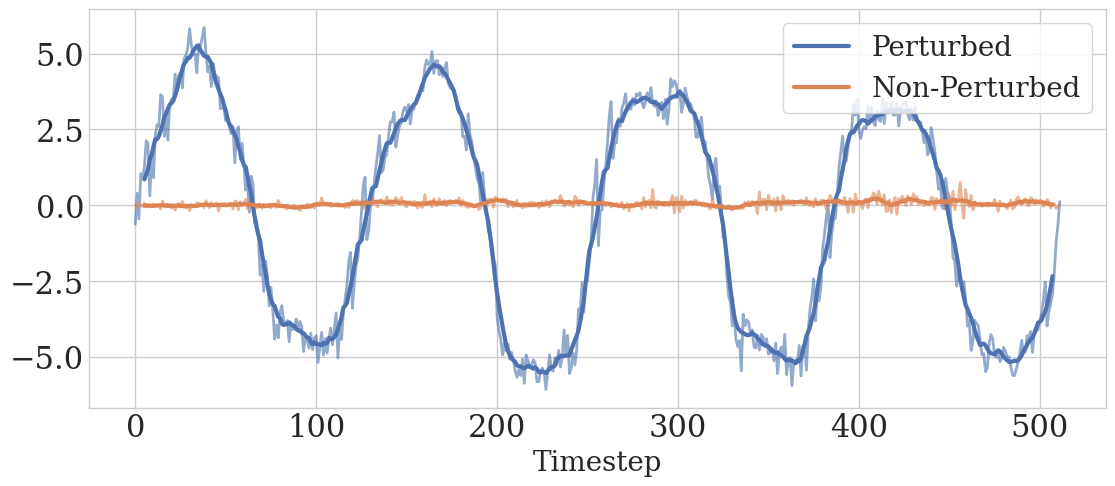

In [6]:
def plot_imputed_signals_with_smoothing(imputed_normal, imputed_perturbed, window_size=10, save_path=None):
    """
    Plot imputed signals (normal and perturbed) for time series data with smoothing.
    Show non-smoothed series in pale colors and smoothed series in bold colors.
    
    Parameters:
    - imputed_normal: The normal imputed signal (numpy array).
    - imputed_perturbed: The perturbed imputed signal (numpy array).
    - window_size: The window size for the moving average smoothing.
    - save_path: If provided, saves the plot to this path as PDF.
    """
    palette = sns.color_palette()
    # Convert arrays to pandas Series and apply rolling window (moving average)
    imputed_normal_smoothed = pd.Series(imputed_normal).rolling(window=window_size, center=True).mean()
    imputed_perturbed_smoothed = pd.Series(imputed_perturbed).rolling(window=window_size, center=True).mean()

    # Set style and fonts for the plot
    sns.set(font_scale=2.0, style="ticks")
    # use seaborn v08 white grid
    plt.style.use('seaborn-v0_8-whitegrid')

    plt.rc('font', family='serif')  # Ensure serif font is used for the plot

    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot non-smoothed series in pale colors (using same colors with alpha for transparency)
    ax.plot(imputed_perturbed, label='Perturbed', color=palette[0], alpha=0.6, linewidth=2)
    ax.plot(imputed_normal, label='Non-Perturbed', color=palette[1], alpha=0.6, linewidth=2)

    # Plot smoothed series in bold colors (using same colors with higher opacity)
    ax.plot(imputed_perturbed_smoothed, label='Perturbed (Smoothed)', color=palette[0], linewidth=3)
    ax.plot(imputed_normal_smoothed, label='Non-Perturbed (Smoothed)', color=palette[1], linewidth=3)

    # Title and labels with explicit font size
    #ax.set_title("Steering Effect on Model Output", fontsize=20)
    ax.set_xlabel("Timestep", fontsize=20)

    # Add legend
    ax.legend(loc='best', fontsize=20)

    handles, labels = ax.get_legend_handles_labels()
    # remove smoothed word from the perturbed (smoothed) and non-perturbed (smoothed) labels
    # remvoe at all the perturbed and non-perturbed labels
    labels = [label.replace(' (Smoothed)', '') for label in labels]
    # remove the pale lines from the legend
    handles = [handles[2], handles[3]]
    ax.legend(handles, labels, loc='best', fontsize=20, frameon=True)
    
    # Adjust layout for clarity
    plt.tight_layout(pad=2)

    # Save as PDF if path is provided
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')

    # Show the plot
    plt.show()

# Example usage
plot_imputed_signals_with_smoothing(non_perturbed_output, perturbed_output, save_path=PLOT_SAVE_PATH)